# Loan Approval System — Model Building, Evaluation, Explainability & Fairness

This notebook picks up after preprocessing and covers:
model training and selection, threshold-based evaluation, SHAP explainability,
a fairness audit, and packaging everything into one reusable prediction function.

## Setup

In [1]:
import json
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference,
    selection_rate, true_positive_rate, false_positive_rate,
)
from sklearn.metrics import accuracy_score

In [2]:
preprocessor = joblib.load("../models/preprocessor.joblib")
X_train, X_val, X_test, y_train, y_val, y_test = joblib.load("../models/splits_raw.joblib")
X_train_processed, X_val_processed, X_test_processed = joblib.load("../models/splits_processed.joblib")
feature_names = preprocessor.get_feature_names_out()

print("Train shape:", X_train_processed.shape, " | Default rate:", y_train.mean().round(4))

Train shape: (104995, 23)  | Default rate: 0.0668


## 1. Model building — baseline, Random Forest, XGBoost

In [3]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg.fit(X_train_processed, y_train)
logreg_probs = logreg.predict_proba(X_val_processed)[:, 1]
logreg_auc, logreg_prauc = roc_auc_score(y_val, logreg_probs), average_precision_score(y_val, logreg_probs)

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                             class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)
rf_probs = rf.predict_proba(X_val_processed)[:, 1]
rf_auc, rf_prauc = roc_auc_score(y_val, rf_probs), average_precision_score(y_val, rf_probs)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_baseline = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
                              random_state=42, n_jobs=-1)
xgb_baseline.fit(X_train_processed, y_train)
xgb_probs = xgb_baseline.predict_proba(X_val_processed)[:, 1]
xgb_auc, xgb_prauc = roc_auc_score(y_val, xgb_probs), average_precision_score(y_val, xgb_probs)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [logreg_auc, rf_auc, xgb_auc],
    "PR-AUC": [logreg_prauc, rf_prauc, xgb_prauc],
}).sort_values("PR-AUC", ascending=False)

print(comparison.to_string(index=False))

              Model  ROC-AUC   PR-AUC
      Random Forest 0.859432 0.368416
            XGBoost 0.860301 0.368380
Logistic Regression 0.847905 0.351482


### Hyperparameter tuning (XGBoost)

In [4]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
                             random_state=42, n_jobs=-1),
    param_distributions=param_dist, n_iter=25, scoring="average_precision",
    cv=3, random_state=42, n_jobs=-1, verbose=1,
)
xgb_search.fit(X_train_processed, y_train)

best_xgb = xgb_search.best_estimator_
val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]
tuned_auc, tuned_prauc = roc_auc_score(y_val, val_probs), average_precision_score(y_val, val_probs)

print("Best params:", xgb_search.best_params_)
print(f"Tuned XGBoost — ROC-AUC: {tuned_auc:.4f}  PR-AUC: {tuned_prauc:.4f}")
print(f"(Untuned was — ROC-AUC: {xgb_auc:.4f}  PR-AUC: {xgb_prauc:.4f})")

joblib.dump(best_xgb, "../models/best_model.joblib")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'subsample': 0.6, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Tuned XGBoost — ROC-AUC: 0.8605  PR-AUC: 0.3685
(Untuned was — ROC-AUC: 0.8603  PR-AUC: 0.3684)


['../models/best_model.joblib']

## 2. Evaluation 

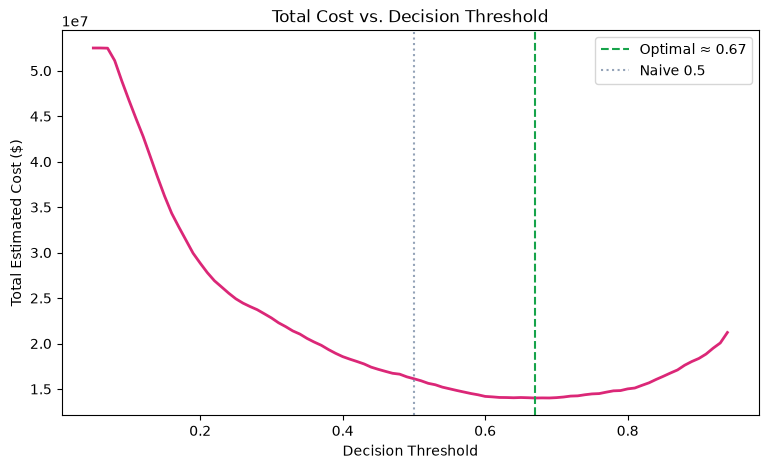

Optimal threshold: 0.67  (cost $14,012,500, vs $16,127,500 at 0.5)


In [5]:
AVG_LOAN_AMOUNT = 15000    # cost of a false negative (approved a defaulter)
AVG_LOST_INTEREST = 2500   # cost of a false positive (rejected a good applicant)

def total_cost_at_threshold(threshold, y_true, probs):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return (fn * AVG_LOAN_AMOUNT) + (fp * AVG_LOST_INTEREST)

thresholds_sweep = np.arange(0.05, 0.95, 0.01)
costs = np.array([total_cost_at_threshold(t, y_val, val_probs) for t in thresholds_sweep])
best_threshold = thresholds_sweep[np.argmin(costs)]

plt.figure(figsize=(9, 5))
plt.plot(thresholds_sweep, costs, color="#DB2777", linewidth=2)
plt.axvline(best_threshold, color="#16A34A", linestyle="--", label=f"Optimal ≈ {best_threshold:.2f}")
plt.axvline(0.5, color="#94A3B8", linestyle=":", label="Naive 0.5")
plt.xlabel("Decision Threshold"); plt.ylabel("Total Estimated Cost ($)")
plt.title("Total Cost vs. Decision Threshold"); plt.legend()
plt.show()

naive_cost = total_cost_at_threshold(0.5, y_val, val_probs)
print(f"Optimal threshold: {best_threshold:.2f}  (cost ${costs.min():,.0f}, vs ${naive_cost:,.0f} at 0.5)")

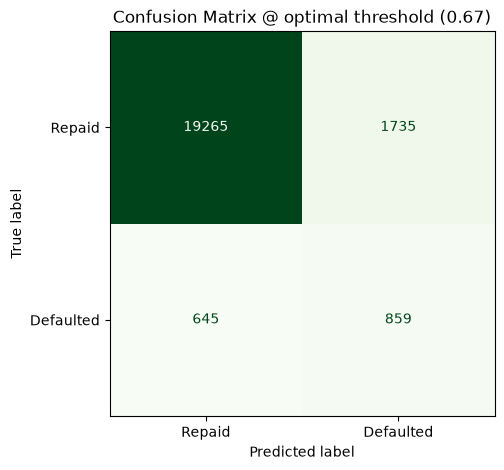

              precision    recall  f1-score   support

      Repaid       0.97      0.92      0.94     21000
   Defaulted       0.33      0.57      0.42      1504

    accuracy                           0.89     22504
   macro avg       0.65      0.74      0.68     22504
weighted avg       0.93      0.89      0.91     22504



In [6]:
val_preds_optimal = (val_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_val, val_preds_optimal)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Repaid", "Defaulted"]).plot(ax=ax, cmap="Greens", colorbar=False)
plt.title(f"Confusion Matrix @ optimal threshold ({best_threshold:.2f})")
plt.show()

print(classification_report(y_val, val_preds_optimal, target_names=["Repaid", "Defaulted"]))

### Three-tier decision system

In [7]:
REVIEW_BAND = 0.15
REVIEW_THRESHOLD = best_threshold - (REVIEW_BAND / 2)
REJECT_THRESHOLD = best_threshold + (REVIEW_BAND / 2)

def decide(score, review_t=REVIEW_THRESHOLD, reject_t=REJECT_THRESHOLD):
    if score >= reject_t:
        return "Reject"
    elif score >= review_t:
        return "Manual Review"
    return "Approve"

val_decisions = pd.Series([decide(s) for s in val_probs])
check_df = pd.DataFrame({"decision": val_decisions.values, "actual": y_val.values})

print(val_decisions.value_counts(normalize=True).round(3) * 100)
print()
print("Default rate by tier (sanity check — should increase Approve -> Review -> Reject):")
print(check_df.groupby("decision")["actual"].mean().round(4))

thresholds_dict = {
    "approve_below": REVIEW_THRESHOLD,
    "reject_at_or_above": REJECT_THRESHOLD,
    "optimal_single_threshold": best_threshold,
}
joblib.dump(thresholds_dict, "../models/decision_thresholds.joblib")
print(thresholds_dict)

Approve          84.1
Reject            8.8
Manual Review     7.1
Name: proportion, dtype: float64

Default rate by tier (sanity check — should increase Approve -> Review -> Reject):
decision
Approve          0.0275
Manual Review    0.1466
Reject           0.3790
Name: actual, dtype: float64
{'approve_below': np.float64(0.5950000000000002), 'reject_at_or_above': np.float64(0.7450000000000001), 'optimal_single_threshold': np.float64(0.6700000000000002)}


## 3. Explainability — SHAP

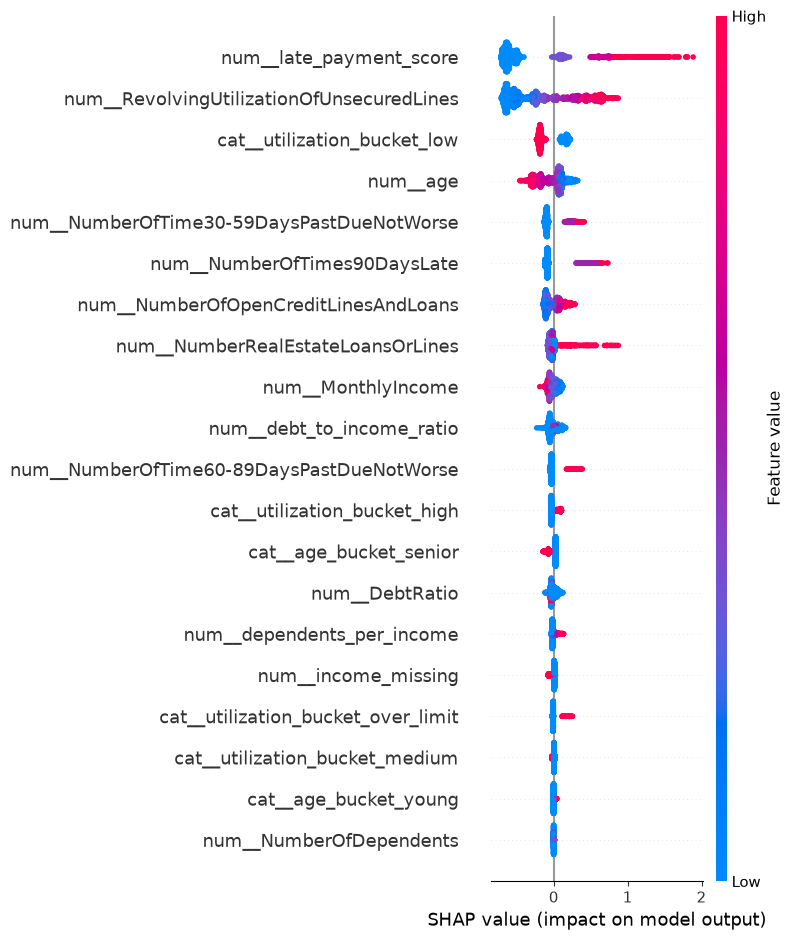

In [8]:
explainer = shap.TreeExplainer(best_xgb)

sample_size = min(2000, X_val_processed.shape[0])
sample_idx = np.random.RandomState(42).choice(X_val_processed.shape[0], sample_size, replace=False)
X_val_sample = X_val_processed[sample_idx]
shap_values = explainer.shap_values(X_val_sample)

shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("../models/shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Human-readable labels for reason codes — covers both numeric and one-hot encoded features
FEATURE_LABELS = {
    "num__RevolvingUtilizationOfUnsecuredLines": "credit utilization",
    "num__age": "applicant age",
    "num__DebtRatio": "debt-to-income ratio",
    "num__MonthlyIncome": "monthly income",
    "num__NumberOfOpenCreditLinesAndLoans": "number of open credit lines",
    "num__NumberRealEstateLoansOrLines": "number of real estate loans",
    "num__NumberOfDependents": "number of dependents",
    "num__income_missing": "missing income information",
    "num__dependents_missing": "missing dependents information",
    "num__debt_to_income_ratio": "debt-to-income ratio",
    "num__late_payment_score": "history of late payments",
    "num__dependents_per_income": "dependents relative to income",
    "num__NumberOfTime30-59DaysPastDueNotWorse": "30-59 day late payments",
    "num__NumberOfTime60-89DaysPastDueNotWorse": "60-89 day late payments",
    "num__NumberOfTimes90DaysLate": "90+ day late payments",
    "cat__utilization_bucket_low": "low credit utilization",
    "cat__utilization_bucket_medium": "moderate credit utilization",
    "cat__utilization_bucket_high": "high credit utilization",
    "cat__utilization_bucket_over_limit": "over-limit credit utilization",
    "cat__age_bucket_young": "younger applicant age",
    "cat__age_bucket_early_career": "early-career applicant age",
    "cat__age_bucket_mid_career": "mid-career applicant age",
    "cat__age_bucket_senior": "senior applicant age",
}

def get_reason_codes(shap_row, feature_names_arr, top_n=3):
    contributions = sorted(zip(feature_names_arr, shap_row), key=lambda x: abs(x[1]), reverse=True)
    reasons = []
    for feat_name, value in contributions[:top_n]:
        readable = FEATURE_LABELS.get(feat_name, feat_name.split("__")[-1].replace("_", " "))
        direction = "increased risk" if value > 0 else "decreased risk"
        reasons.append(f"{readable.capitalize()} {direction}")
    return reasons

Applicant risk score: 0.676
Top reasons:
  - Credit utilization increased risk
  - History of late payments decreased risk
  - Number of open credit lines increased risk


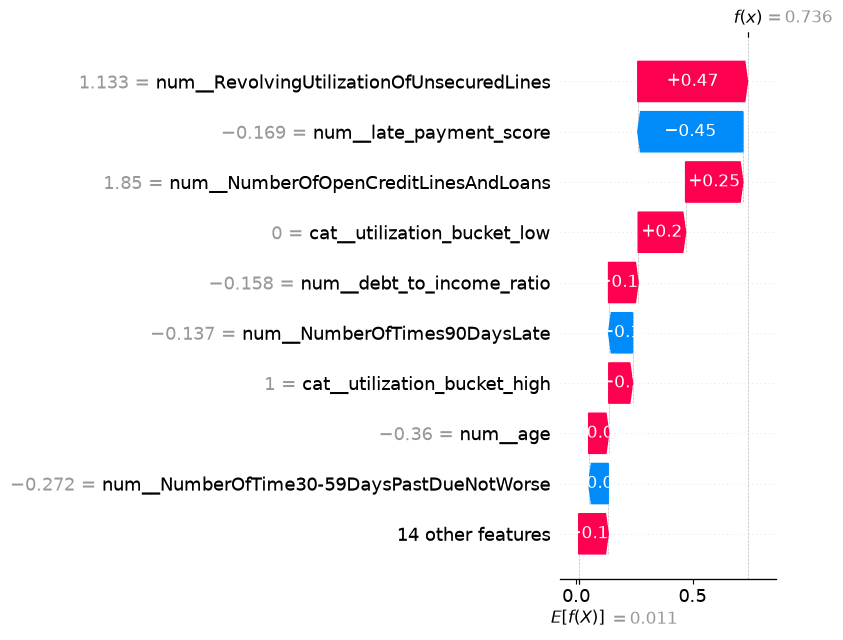

In [10]:
# Explain one applicant from the "Manual Review" band — where explanations matter most
val_probs_sample = best_xgb.predict_proba(X_val_sample)[:, 1]
review_mask = (val_probs_sample >= thresholds_dict["approve_below"]) & (val_probs_sample < thresholds_dict["reject_at_or_above"])
review_indices = np.where(review_mask)[0]
applicant_idx = review_indices[0] if len(review_indices) > 0 else 0

print(f"Applicant risk score: {val_probs_sample[applicant_idx]:.3f}")
print("Top reasons:")
for r in get_reason_codes(shap_values[applicant_idx], feature_names, top_n=3):
    print(f"  - {r}")

explanation = shap.Explanation(
    values=shap_values[applicant_idx], base_values=explainer.expected_value,
    data=X_val_sample[applicant_idx], feature_names=feature_names,
)
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig("../models/shap_waterfall_example.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed, feature_names=feature_names,
    class_names=["Repaid", "Defaulted"], mode="classification", random_state=42,
)
lime_exp = lime_explainer.explain_instance(X_val_sample[applicant_idx], best_xgb.predict_proba, num_features=5)

print("LIME top features for the same applicant:")
for feat, weight in lime_exp.as_list():
    print(f"  {feat}: {weight:.4f}")

joblib.dump(explainer, "../models/shap_explainer.joblib")
joblib.dump(FEATURE_LABELS, "../models/feature_labels.joblib")

LIME top features for the same applicant:
  num__late_payment_score <= -0.17: -0.3981
  num__RevolvingUtilizationOfUnsecuredLines > 0.68: 0.1791
  num__NumberOfTimes90DaysLate <= -0.14: -0.1334
  num__NumberOfTime30-59DaysPastDueNotWorse <= -0.27: -0.0611
  cat__utilization_bucket_low <= 0.00: 0.0572


['../models/feature_labels.joblib']

## 4. Fairness audit — age group

In [12]:
age_groups = pd.cut(X_val["age"], bins=[0, 30, 45, 60, 120], labels=["18-30", "31-45", "46-60", "60+"])
val_preds_for_fairness = (val_probs >= thresholds_dict["optimal_single_threshold"]).astype(int)

metric_frame = MetricFrame(
    metrics={"selection_rate": selection_rate, "accuracy": accuracy_score,
             "true_positive_rate": true_positive_rate, "false_positive_rate": false_positive_rate},
    y_true=y_val, y_pred=val_preds_for_fairness, sensitive_features=age_groups,
)
print(metric_frame.by_group)

dp_diff = demographic_parity_difference(y_val, val_preds_for_fairness, sensitive_features=age_groups)
eo_diff = equalized_odds_difference(y_val, val_preds_for_fairness, sensitive_features=age_groups)
print(f"\nDemographic parity difference: {dp_diff:.4f}")
print(f"Equalized odds difference:     {eo_diff:.4f}")

       selection_rate  accuracy  true_positive_rate  false_positive_rate
age                                                                     
18-30        0.199490  0.822817            0.603550             0.150714
31-45        0.165663  0.853539            0.602076             0.120352
46-60        0.119250  0.893375            0.594393             0.085198
60+          0.045508  0.948601            0.409910             0.033191

Demographic parity difference: 0.1540
Equalized odds difference:     0.1936


### Mitigation — manual per-group threshold calibration


In [13]:
def find_group_threshold(mask, target_rate, probs):
    candidates = np.arange(0.05, 0.95, 0.01)
    diffs = [abs((probs[mask] < t).mean() - target_rate) for t in candidates]
    return candidates[int(np.argmin(diffs))]

overall_approval_rate = (val_probs < thresholds_dict["optimal_single_threshold"]).mean()
group_thresholds = {
    g: find_group_threshold((age_groups == g).to_numpy(), overall_approval_rate, val_probs)
    for g in age_groups.cat.categories
}
print("Calibrated thresholds per group:", group_thresholds)

adjusted_preds = np.zeros(len(val_probs), dtype=int)
for g, t in group_thresholds.items():
    mask = (age_groups == g).to_numpy()
    adjusted_preds[mask] = (val_probs[mask] >= t).astype(int)

adjusted_dp_diff = demographic_parity_difference(y_val, adjusted_preds, sensitive_features=age_groups)
acc_before = accuracy_score(y_val, val_preds_for_fairness)
acc_after = accuracy_score(y_val, adjusted_preds)

print(f"\nDemographic parity difference — before: {dp_diff:.4f}  after: {adjusted_dp_diff:.4f}")
print(f"Accuracy — before: {acc_before:.4f}  after: {acc_after:.4f}  (trade-off: {(acc_before-acc_after)*100:.2f} pts)")

fairness_results = {
    "sensitive_attribute": "age_group",
    "demographic_parity_difference": dp_diff,
    "equalized_odds_difference": eo_diff,
    "dp_diff_after_mitigation": adjusted_dp_diff,
    "accuracy_before": acc_before,
    "accuracy_after": acc_after,
}
joblib.dump(fairness_results, "../models/fairness_audit_results.joblib")

Calibrated thresholds per group: {'18-30': np.float64(0.8400000000000002), '31-45': np.float64(0.7700000000000002), '46-60': np.float64(0.6800000000000002), '60+': np.float64(0.42000000000000004)}

Demographic parity difference — before: 0.1540  after: 0.0045
Accuracy — before: 0.8942  after: 0.8902  (trade-off: 0.40 pts)


['../models/fairness_audit_results.joblib']

## 5. Packaging — one reusable prediction function



In [14]:
NUMERIC_FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans", "NumberRealEstateLoansOrLines",
    "NumberOfDependents", "income_missing", "dependents_missing",
    "debt_to_income_ratio", "late_payment_score", "dependents_per_income",
    "NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]
CATEGORICAL_FEATURES = ["utilization_bucket", "age_bucket"]

def engineer_features(raw_input: dict) -> pd.DataFrame:
    monthly_income = raw_input.get("MonthlyIncome")
    income_missing = int(monthly_income is None or pd.isna(monthly_income))
    monthly_income_filled = monthly_income if not income_missing else 6000

    dependents = raw_input.get("NumberOfDependents")
    dependents_missing = int(dependents is None or pd.isna(dependents))
    dependents_filled = dependents if not dependents_missing else 0

    debt_ratio = raw_input["DebtRatio"]
    debt_to_income_ratio = debt_ratio * monthly_income_filled / (monthly_income_filled + 1)

    late_30_59 = min(raw_input["NumberOfTime30-59DaysPastDueNotWorse"], 18)
    late_60_89 = min(raw_input["NumberOfTime60-89DaysPastDueNotWorse"], 18)
    late_90 = min(raw_input["NumberOfTimes90DaysLate"], 18)
    late_payment_score = late_30_59 * 1 + late_60_89 * 2 + late_90 * 3
    dependents_per_income = dependents_filled / (monthly_income_filled + 1)

    utilization = min(raw_input["RevolvingUtilizationOfUnsecuredLines"], 2.0)
    utilization_bucket = ("low" if utilization <= 0.3 else "medium" if utilization <= 0.6
                           else "high" if utilization <= 1.0 else "over_limit")

    age = raw_input["age"]
    age_bucket = ("young" if age <= 30 else "early_career" if age <= 45
                  else "mid_career" if age <= 60 else "senior")

    row = {
        "RevolvingUtilizationOfUnsecuredLines": utilization, "age": age, "DebtRatio": debt_ratio,
        "MonthlyIncome": monthly_income_filled,
        "NumberOfOpenCreditLinesAndLoans": raw_input["NumberOfOpenCreditLinesAndLoans"],
        "NumberRealEstateLoansOrLines": raw_input["NumberRealEstateLoansOrLines"],
        "NumberOfDependents": dependents_filled, "income_missing": income_missing,
        "dependents_missing": dependents_missing, "debt_to_income_ratio": debt_to_income_ratio,
        "late_payment_score": late_payment_score, "dependents_per_income": dependents_per_income,
        "NumberOfTime30-59DaysPastDueNotWorse": late_30_59,
        "NumberOfTime60-89DaysPastDueNotWorse": late_60_89,
        "NumberOfTimes90DaysLate": late_90,
        "utilization_bucket": utilization_bucket, "age_bucket": age_bucket,
    }
    return pd.DataFrame([row])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

def predict_applicant(raw_input: dict) -> dict:
    X_row = engineer_features(raw_input)
    X_processed = preprocessor.transform(X_row)
    risk_score = float(best_xgb.predict_proba(X_processed)[:, 1][0])
    decision = decide(risk_score, thresholds_dict["approve_below"], thresholds_dict["reject_at_or_above"])
    shap_row = explainer.shap_values(X_processed)[0]
    reasons = get_reason_codes(shap_row, feature_names, top_n=3)
    return {"risk_score": round(risk_score, 4), "decision": decision, "reason_codes": reasons,
            "timestamp": datetime.now().isoformat()}

In [15]:
sample_applicant = {
    "RevolvingUtilizationOfUnsecuredLines": 0.45, "age": 34, "DebtRatio": 0.6,
    "MonthlyIncome": 4200, "NumberOfOpenCreditLinesAndLoans": 6, "NumberRealEstateLoansOrLines": 1,
    "NumberOfDependents": 2, "NumberOfTime30-59DaysPastDueNotWorse": 1,
    "NumberOfTime60-89DaysPastDueNotWorse": 0, "NumberOfTimes90DaysLate": 0,
}
result = predict_applicant(sample_applicant)
print(f"Risk score: {result['risk_score']}  |  Decision: {result['decision']}")
print("Reasons:")
for r in result["reason_codes"]:
    print(f"  - {r}")

bundle_manifest = {
    "model_file": "best_model.joblib", "preprocessor_file": "preprocessor.joblib",
    "shap_explainer_file": "shap_explainer.joblib", "feature_labels_file": "feature_labels.joblib",
    "thresholds_file": "decision_thresholds.joblib", "created": datetime.now().isoformat(),
}
with open("../models/bundle_manifest.json", "w") as f:
    json.dump(bundle_manifest, f, indent=2)
print("\nAll artifacts saved. Ready for the Streamlit app.")

Risk score: 0.5517  |  Decision: Approve
Reasons:
  - 30-59 day late payments increased risk
  - Low credit utilization increased risk
  - Applicant age increased risk

All artifacts saved. Ready for the Streamlit app.
